# Exercise 2b: Feature engineering

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
X_train = pd.read_csv("ex2_train.csv")
y_train = pd.read_csv("ex2_class_train.csv")
X_test = pd.read_csv("ex2_test.csv")
y_test = pd.read_csv("ex2_class_test.csv")

In [3]:
X_train.describe()

,Pclass,Age,SibSp,Parch,Fare
count,712.000000,572.000000,712.000000,712.000000,712.000000
mean,2.330056,29.498846,0.553371,0.379213,32.586276
std,0.824584,14.500059,1.176404,0.791669,51.969529
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,2.000000,21.000000,0.000000,0.000000,7.925000
50%,3.000000,28.000000,0.000000,0.000000,14.454200
75%,3.000000,38.000000,1.000000,0.000000,30.500000
max,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
# define a utility function to print out the prediction performance
def evaluate_result(y_test, y_pred, clf):
    print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
    print(f'Precision: {precision_score(y_test, y_pred):.4f}')
    print(f'Recall: {recall_score(y_test, y_pred):.4f}')
    print(f'F1-score: {f1_score(y_test, y_pred):.4f}')
    print(f'AUC-ROC: {roc_auc_score(y_test, clf.predict_proba(X_test_processed)[:, 1]):.4f}')

## Prototyping (without feature engineering)

In [5]:
def preprocess(data_in):
    data = data_in.drop(columns=['Name'])
    
    data = data.fillna({
        'Age': data['Age'].median(),
        'Embarked': data['Embarked'].mode(dropna=True).iloc[0],
        'Fare': data['Fare'].median()
    })

    # Convert categorical variables to dummy/indicator variables
    data = pd.get_dummies(data, columns=['Sex', 'Embarked'], drop_first=True)

    return data

In [6]:
X_train_processed = preprocess(X_train)
X_test_processed = preprocess(X_test)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_processed, y_train.values.ravel())
y_pred = clf.predict(X_test_processed)

print('Random Forest Model without Feature Engineering')
evaluate_result(y_test, y_pred, clf)

Random Forest Model without Feature Engineering
Accuracy: 0.8101
Precision: 0.7778
Recall: 0.7568
F1-score: 0.7671
AUC-ROC: 0.8736


## Feature engineering

The classification using simple preprocessed data gives only mediocre performance.

**TODO: You should make use of the insights from your EDA (ex2a) to complete the following feature engineering function below.** Later the function will replace the simple preprocessing.

You will pass the exercise if your feature engineering can improve the performance (i.e., winning in three or more metrics).

In [18]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

def feature_engineering(data_in):
    df = data_in.copy()
    df = df.drop(columns=['Name'])

    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1    

    df = df.fillna({
        'Age': df['Age'].median(),
        'Embarked': df['Embarked'].mode(dropna=True).iloc[0]
    })


    # Convert categorical variables to dummy/indicator variables
    df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)
    
    """
    imp = IterativeImputer(random_state=0)
    imp.fit(df)
    imputed_array = imp.transform(df)
    df["Age"] = imputed_array[:, df.columns.get_loc('Age')]
    """

    return df

In [19]:
X_train_processed = feature_engineering(X_train)
X_test_processed = feature_engineering(X_test)

print(X_train_processed[20:30])

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_processed, y_train.values.ravel())
y_pred = clf.predict(X_test_processed)

print('Random Forest Model with Feature Engineering')
evaluate_result(y_test, y_pred, clf)

    Pclass   Age  SibSp  Parch      Fare  FamilySize  Sex_male  Embarked_Q  \
20       3  11.0      4      2   31.2750           7     False       False   
21       3  61.0      0      0    6.2375           1      True       False   
22       3  30.0      0      0    8.6625           1     False       False   
23       2   7.0      0      2   26.2500           3     False       False   
24       3  63.0      0      0    9.5875           1     False       False   
25       3  20.0      0      0    7.2292           1      True       False   
26       3  28.0      0      2   22.3583           3     False       False   
27       3  29.0      0      0    9.4833           1      True       False   
28       1  36.0      1      2  120.0000           4      True       False   
29       3  28.0      0      0   14.4583           1      True       False   

    Embarked_S  
20        True  
21        True  
22        True  
23        True  
24        True  
25       False  
26       False  
27   

**Iterative Imputation**  
Accuracy: 0.8101  
Precision: 0.8030  
Recall: 0.7162  
F1-score: 0.7571  
AUC-ROC: 0.8916

**Median**  
Accuracy: 0.8156  
Precision: 0.7808  
Recall: 0.7703  
F1-score: 0.7755  
AUC-ROC: 0.8821  

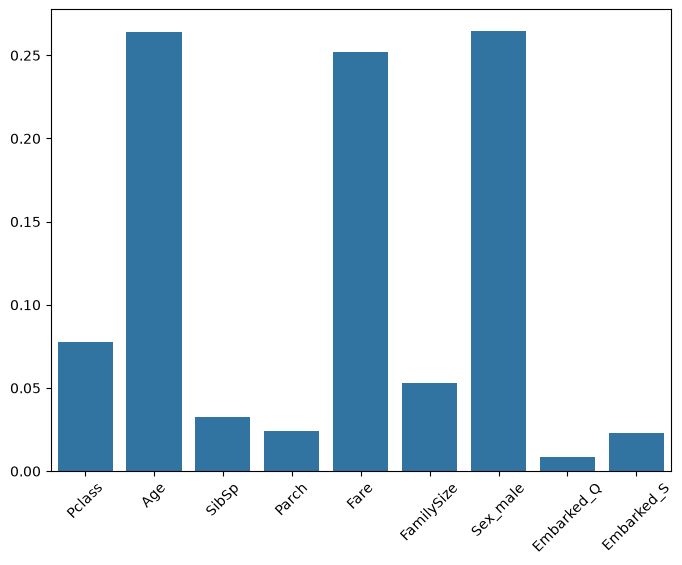

In [9]:
plt.figure(figsize=(8, 6))
plt.tight_layout()
plt.xticks(rotation=45)
sns.barplot(x=clf.feature_names_in_, y=clf.feature_importances_)
plt.show()